In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent  # active/
sys.path.insert(0, str(project_root))

In [2]:
# problems
# acquisitions
from src.acquisition.alc import alcSampling
from src.acquisition.alm import almSampling

# data
from src.data.dataset import MultiFidelityDataset

# evalutaion
from src.evaluation.grid import Evaluator

# initial design
from src.initial_design.nested_lhs import NestedLHS
from src.initial_design.nested_mmlhs import NestedMMLHS
from src.problems.branin import Branin

# sampler 
from src.sampler.experiment import Experiment

# surrogates
from src.surrogates.ResidualCoKriging import ResidualCoKriging

# visualization
from src.visualization.active_learning_plots import ActiveLearningPlotter


### Funionamento degli oggetti "problema"

In [3]:
problem = Branin()

In [4]:
design = NestedMMLHS(
    n_low=120,
    n_high=10
)

In [5]:
points = design.generate(problem) # ritorna un dict

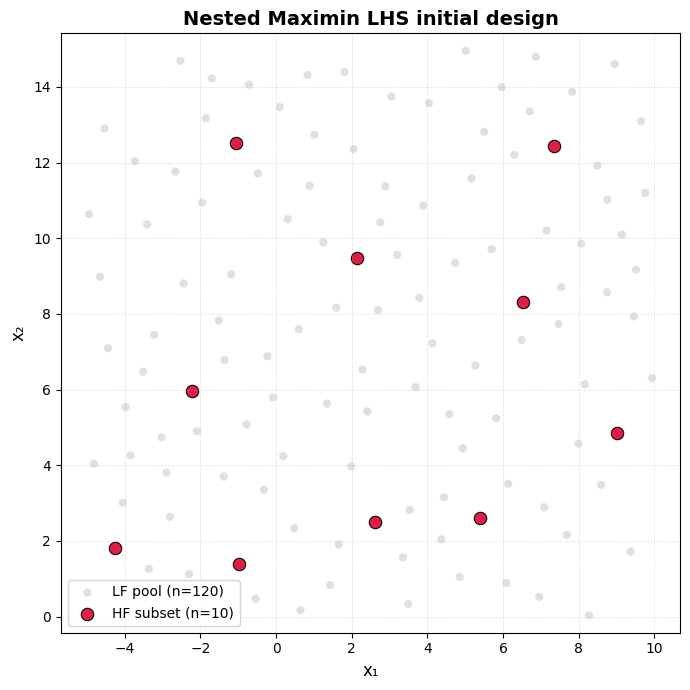

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))


# ==========================================================
# LF design
# ==========================================================

plt.scatter(
    points["X_low"][:, 0],
    points["X_low"][:, 1],
    c="lightgray",
    edgecolor="none",
    alpha=0.7,
    s=35,
    label=f"LF pool (n={len(points['X_low'])})"
)


# ==========================================================
# HF design
# ==========================================================

plt.scatter(
    points["X_high"][:, 0],
    points["X_high"][:, 1],
    c="crimson",
    edgecolor="black",
    linewidth=0.8,
    alpha=0.95,
    s=80,
    marker="o",
    label=f"HF subset (n={len(points['X_high'])})"
)


# ==========================================================
# Formatting
# ==========================================================

plt.xlabel(
    "x₁",
    fontsize=12
)

plt.ylabel(
    "x₂",
    fontsize=12
)


plt.title(
    "Nested Maximin LHS initial design",
    fontsize=14,
    fontweight="bold"
)


plt.grid(
    True,
    linestyle="--",
    linewidth=0.5,
    alpha=0.4
)


plt.axis("equal")


plt.legend(
    frameon=True,
    fontsize=10,
    loc="best"
)


plt.tight_layout()

plt.show()

In [7]:
dataset = MultiFidelityDataset(

    X_low=points["X_low"],
    y_low=problem.evaluate_low(points["X_low"]),

    X_high=points["X_high"],
    y_high=problem.evaluate_high(points["X_high"]),

    high_idx=points["high_idx"]

)

In [8]:
surrogate = ResidualCoKriging()

In [9]:
# acquisition = almSampling()
acquisition = alcSampling(problem=problem, n_integration_points=500)

In [10]:
# serve sia per valutare il GP che per salvare la history
evaluator = Evaluator(
    problem,
    n_grid=80,
    seed=42
)

In [ ]:
experiment = Experiment(
    problem,
    dataset,
    surrogate,
    acquisition,
    evaluator,
    budget=20
)

# ritorna dict finale
result = experiment.run()

surrogate_final = result["surrogate"] # surrogates finale
dataset_final = result["dataset"] # dataset finale (HF finali etc)
history = result["history"]

C:\Users\tomma\AppData\Roaming\Python\Python311\site-packages\sklearn\gaussian_process\_gpr.py:663: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\tomma\AppData\Roaming\Python\Python311\site-packages\sklearn\gaussian_process\_gpr.py:663: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\tomma\AppData\Roaming\Python\Python311\site-packages\sklearn\gaussian_process\_gpr.py:663: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as 

valutazione e metriche

In [12]:
evaluation = evaluator.evaluate(
    surrogate_final
)

In [13]:
print(
    "MSE:",
    evaluation["mse"]
)

print(
    "RMSE:",
    evaluation["rmse"]
)

print(
    "MAE:",
    evaluation["mae"]
)

MSE: 6.999289767300767
RMSE: 2.6456170862958923
MAE: 1.649070470680649


In [14]:
plotter = ActiveLearningPlotter(
    problem,
    evaluator
)

### Sampling finale

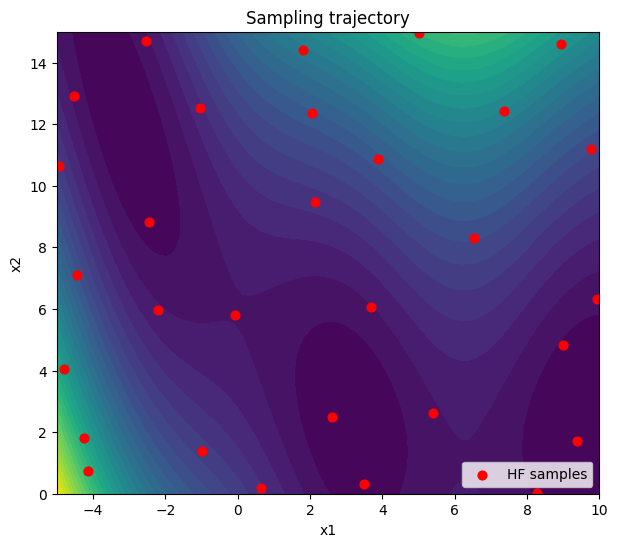

In [15]:
plotter.plot_sampling(
    evaluation["X_test"],
    evaluation["y_true"],
    dataset_final.X_high
)

### Incertezza finale

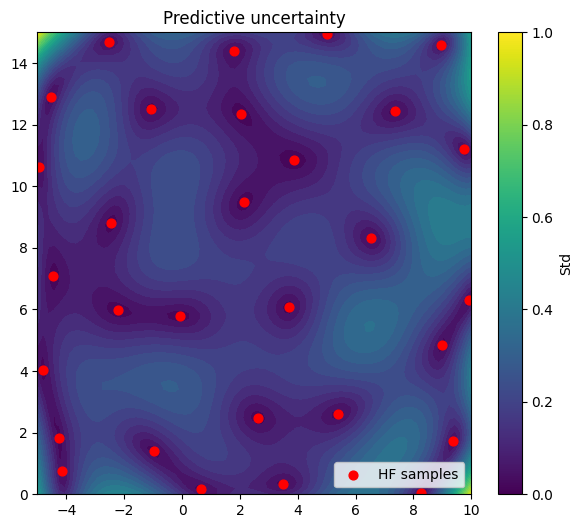

In [16]:
plotter.plot_uncertainty(
    evaluation["X_test"],
    evaluation["std"],
    dataset_final.X_high
)

### Evoluzione incertezza

c:\Users\tomma\OneDrive\Desktop\bayesiana\labs\SALSA\SALSA\src\visualization\active_learning_plots.py:221: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


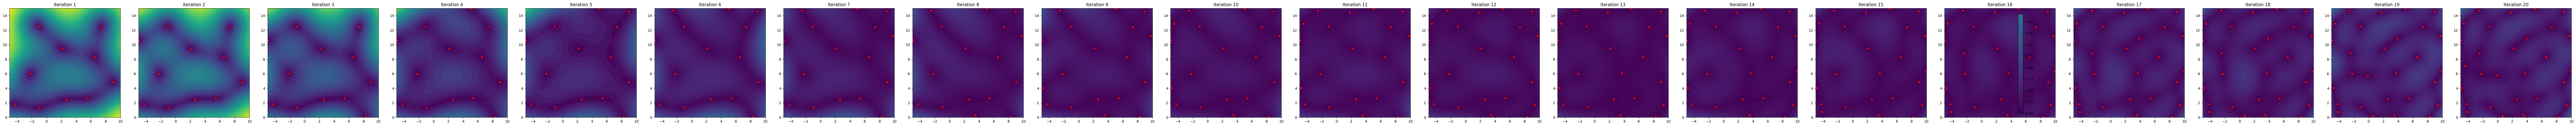

In [17]:
plotter.plot_uncertainty_evolution(
    history
)